
| | |
|---|---|
| **Nhóm** | 4 |
| **Thành viên** | 23730041 - Dương Thanh Quí |
| | 24730010 - Phan Tuấn Anh |
| | 24730004 - Hoàng Quốc Anh |
| **Lớp** | IE224.F21.CN1.CNTT |
| **Học phần** | Phân tích dữ liệu |
| **GVHD** | ThS. Phạm Thế Sơn |

# Đề tài: PHÂN TÍCH VÀ DỰ ĐOÁN GIÁ NHÀ SỬ DỤNG MÔ HÌNH HỒI QUY

## 1. Giới thiệu

Đề tài tập trung phân tích các yếu tố có mối liên hệ với giá nhà và xây dựng
mô hình dự đoán giá dựa trên các đặc trưng như diện tích, số phòng ngủ,
số phòng tắm, tiện nghi và vị trí.

Bộ dữ liệu được sử dụng được thu thập từ
[Kaggle](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset).

Mục tiêu: Xây dựng mô hình hồi quy dự đoán giá nhà (`price`) dựa trên
các thuộc tính còn lại.


In [1]:
import pandas as pd

df = pd.read_csv("./data/Housing.csv")

## 2. Mô tả bộ dữ liệu

In [2]:
df.shape

(545, 13)

Bộ dữ liệu gồm 545 dòng, 13 cột.

In [3]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


Bộ dữ liệu gồm 13 cột:
- 6 cột số (int64): price, area, bedrooms, bathrooms, stories, parking
- 7 cột chữ (object): mainroad, guestroom, basement, hotwaterheating,
airconditioning, prefarea, furnishingstatus. Các biến này sẽ được encode ở bước tiền xử lý.

In [4]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Không có missing values, đây là một bộ dữ liệu sạch.

In [5]:
df.describe().round(2)


,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


- Dataset có 545 dòng (count = 545)
- Giá nhà (price) trung bình ~4.77 triệu, dao động từ 1.75 triệu đến 13.3 triệu
- Diện tích (area) trung bình 5150, dao động từ 1650 đến 16200
- Số phòng ngủ (bedrooms) phổ biến là 3 (median = 3), tối đa 6
- Số phòng tắm (bathrooms) phổ biến là 1, tối đa 4
- Số tầng (stories) trung bình ~1.8, tối đa 4
- Bãi đậu xe (parking) phần lớn là 0 (median = 0), tối đa 3

In [6]:
df.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


Nhận xét các cột chữ:
- 6 cột có 2 giá trị là chữ là: mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea
- 1 cột có 3 giá trị là chữ là: furnishingstatus

In [7]:
for col in df.select_dtypes(include='object').columns:
    print(col, ':', df[col].unique())

mainroad : ['yes' 'no']
guestroom : ['no' 'yes']
basement : ['no' 'yes']
hotwaterheating : ['no' 'yes']
airconditioning : ['yes' 'no']
prefarea : ['yes' 'no']
furnishingstatus : ['furnished' 'semi-furnished' 'unfurnished']


Các giá trị cụ thể từng cột chữ:
- mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea: yes/no
- furnishingstatus: furnished, semi-furnished, unfurnished

## 3. Phương pháp phân tích

Trong phần này, nhóm trình bày các phương pháp được sử dụng để phân tích bộ dữ liệu và xây dựng mô hình dự đoán giá nhà.

Trước hết, dữ liệu được kiểm tra thêm về số lượng bản ghi trùng lặp, kiểu dữ liệu và đặc điểm của từng thuộc tính để xác định cách xử lý phù hợp. Sau đó, nhóm sử dụng thống kê mô tả kết hợp với trực quan hóa để hiểu rõ hơn về phân phối dữ liệu, phát hiện outlier và quan sát xu hướng của biến mục tiêu.

Đối với các biến số, nhóm sử dụng hệ số tương quan Pearson để đánh giá mức độ liên hệ với giá nhà. Đối với các biến phân loại, nhóm so sánh giá nhà giữa các nhóm thông qua bảng thống kê và biểu đồ boxplot.

Sau bước phân tích thăm dò, dữ liệu được mã hóa để phục vụ cho mô hình học máy. Cụ thể, các biến yes/no được chuyển về dạng 0/1 và biến `furnishingstatus` được one-hot encoding. Cuối cùng, nhóm sử dụng mô hình hồi quy tuyến tính đa biến để dự đoán giá nhà và đánh giá mô hình bằng các chỉ số `R²`, `RMSE` và `MAE`.


In [8]:
import os
import sys
import subprocess
import warnings
from pathlib import Path

workspace_candidates = [
    Path.cwd() / "requirements.txt",
    Path.cwd() / "ie224-fp" / "requirements.txt",
]
requirements_path = next((path for path in workspace_candidates if path.exists()), None)
if requirements_path is None:
    raise FileNotFoundError("Không tìm thấy requirements.txt để cài đặt thư viện.")

mpl_dir = Path.cwd() / ".mplconfig"
mpl_dir.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_dir))

required_modules = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
}
missing_packages = []

for module_name, package_name in required_modules.items():
    try:
        __import__(module_name)
    except ModuleNotFoundError:
        missing_packages.append(package_name)

if missing_packages:
    print("Đang cài các thư viện còn thiếu:", ", ".join(missing_packages))
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-r",
        str(requirements_path),
    ])

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [9]:
duplicate_count = df.duplicated().sum()
print(f"Số dòng bị trùng lặp: {duplicate_count}")


Số dòng bị trùng lặp: 0


## 4. Phân tích thăm dò dữ liệu

Phần này tập trung quan sát phân phối của các biến quan trọng, mức độ tương quan giữa các biến số và sự khác biệt về giá nhà theo từng nhóm thuộc tính.


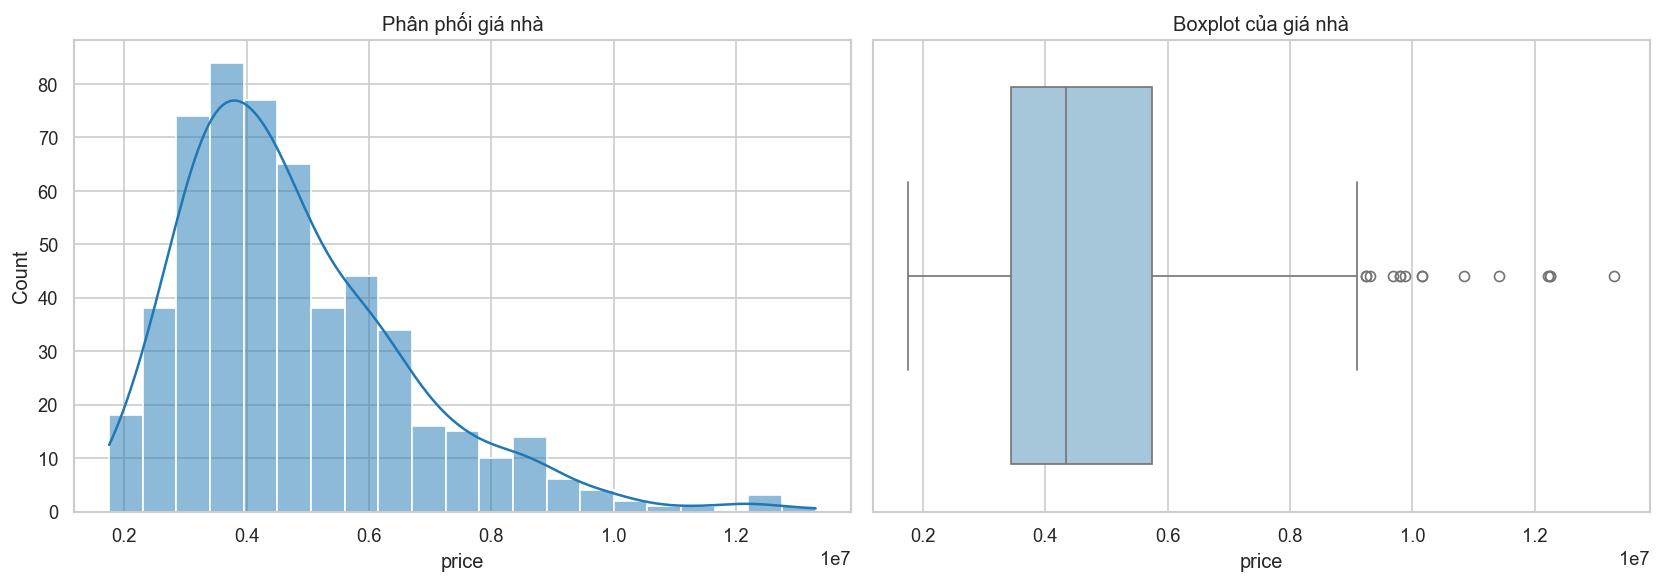

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price"], kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Phân phối giá nhà")
axes[0].set_xlabel("price")

sns.boxplot(x=df["price"], ax=axes[1], color="#9ecae1")
axes[1].set_title("Boxplot của giá nhà")
axes[1].set_xlabel("price")

plt.tight_layout()
plt.show()


Nhìn vào biểu đồ trên, có thể thấy biến `price` có độ phân tán khá lớn và xuất hiện một số giá trị cao vượt trội so với phần còn lại. Điều này cho thấy giá nhà trong bộ dữ liệu không phân bố hoàn toàn đồng đều và có dấu hiệu tồn tại outlier.


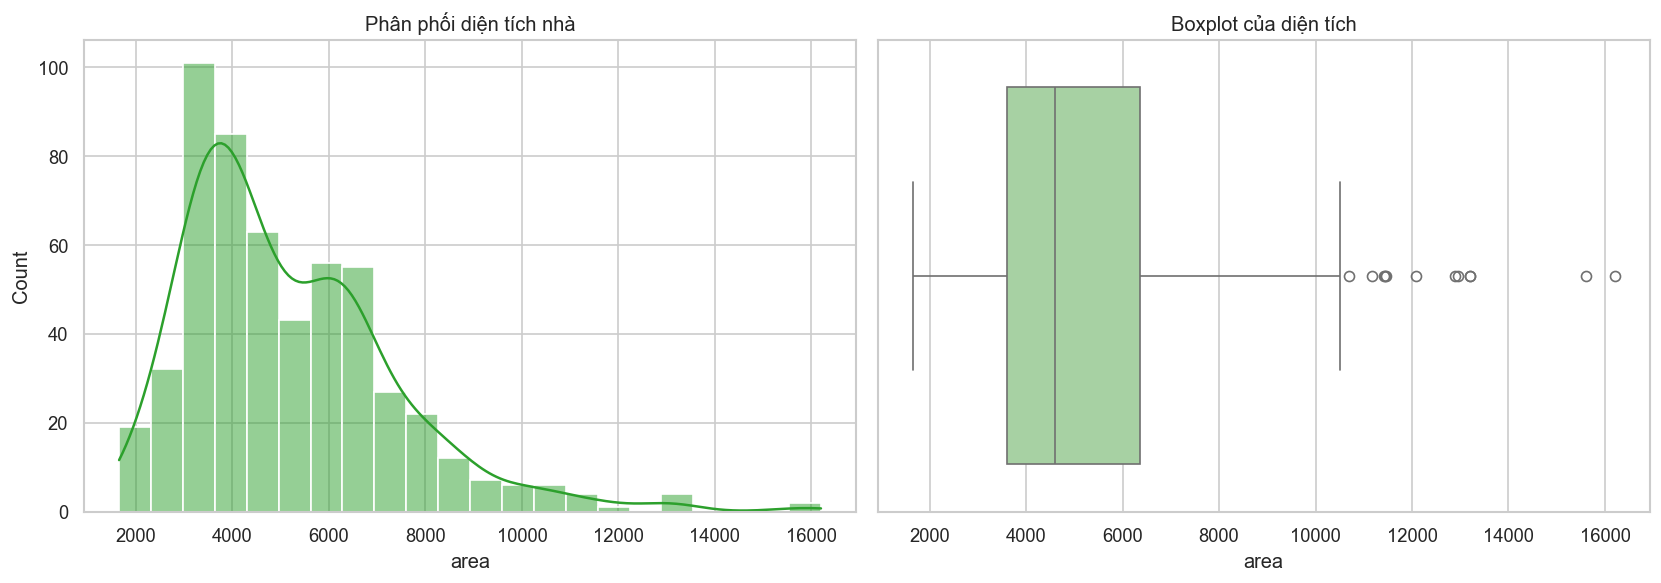

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["area"], kde=True, ax=axes[0], color="#2ca02c")
axes[0].set_title("Phân phối diện tích nhà")
axes[0].set_xlabel("area")

sns.boxplot(x=df["area"], ax=axes[1], color="#a1d99b")
axes[1].set_title("Boxplot của diện tích")
axes[1].set_xlabel("area")

plt.tight_layout()
plt.show()


Biến `area` có xu hướng lệch phải, nghĩa là phần lớn căn nhà có diện tích vừa phải, trong khi chỉ có một số ít căn nhà có diện tích rất lớn. Đặc điểm này thường làm cho giá nhà tăng mạnh ở nhóm có diện tích cao.


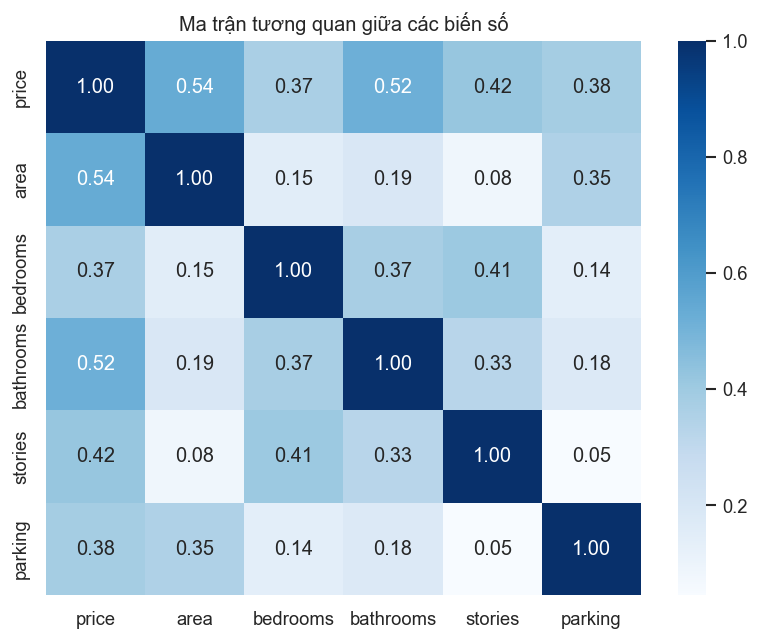

,price
price,1.000000
area,0.535997
bathrooms,0.517545
stories,0.420712
parking,0.384394
bedrooms,0.366494


In [12]:
numeric_cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

corr_matrix["price"].sort_values(ascending=False)


Ma trận tương quan giúp nhóm xác định nhanh các biến số có liên hệ mạnh với `price`. Thông thường, `area`, `bathrooms`, `stories` và `parking` là các biến đáng chú ý vì có tương quan dương với giá nhà.


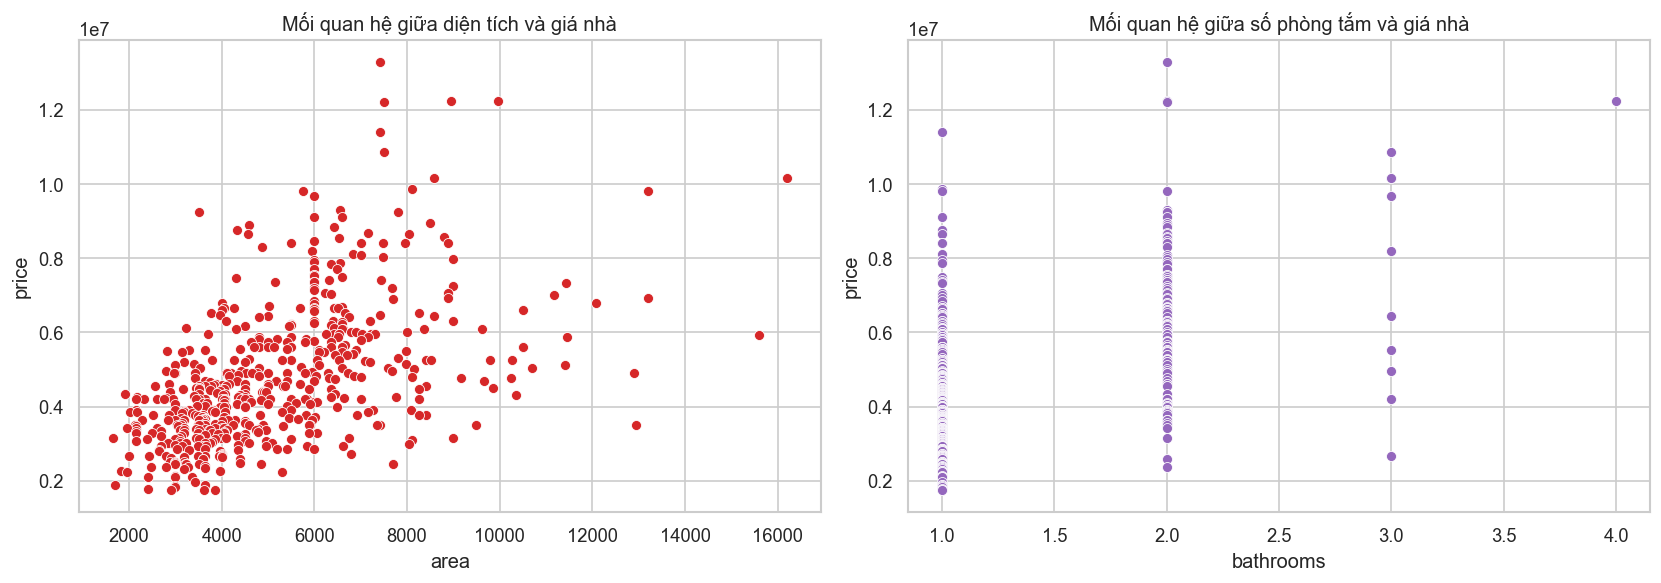

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="area", y="price", ax=axes[0], color="#d62728")
axes[0].set_title("Mối quan hệ giữa diện tích và giá nhà")

sns.scatterplot(data=df, x="bathrooms", y="price", ax=axes[1], color="#9467bd")
axes[1].set_title("Mối quan hệ giữa số phòng tắm và giá nhà")

plt.tight_layout()
plt.show()


Từ scatter plot có thể thấy giá nhà có xu hướng tăng khi diện tích tăng. Bên cạnh đó, số phòng tắm nhiều hơn cũng thường đi kèm với mức giá cao hơn, dù dữ liệu vẫn có độ phân tán tương đối lớn.


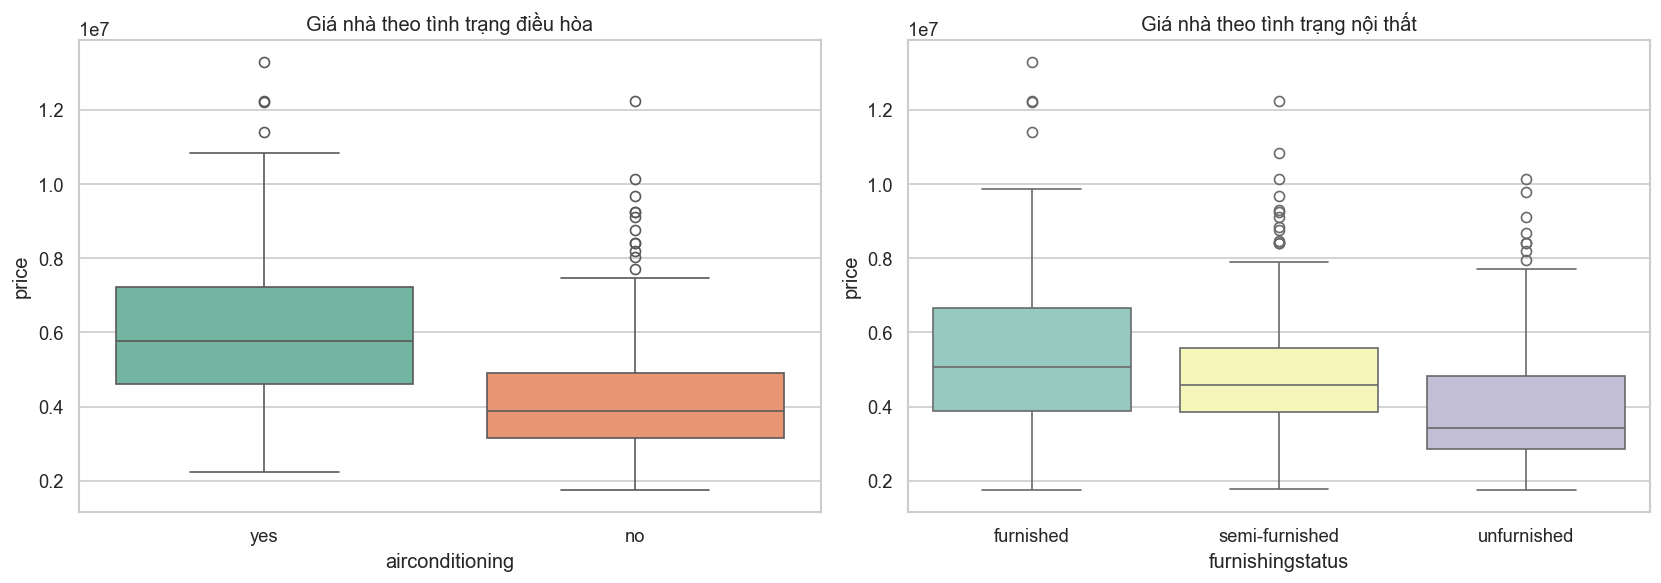

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="airconditioning", y="price", hue="airconditioning", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Giá nhà theo tình trạng điều hòa")
axes[0].set_xlabel("airconditioning")
axes[0].set_ylabel("price")

sns.boxplot(data=df, x="furnishingstatus", y="price", hue="furnishingstatus", ax=axes[1], palette="Set3", legend=False)
axes[1].set_title("Giá nhà theo tình trạng nội thất")
axes[1].set_xlabel("furnishingstatus")
axes[1].set_ylabel("price")

plt.tight_layout()
plt.show()


Các căn nhà có `airconditioning = yes` thường có mức giá cao hơn nhóm không có điều hòa. Ngoài ra, nhóm `furnished` cũng có xu hướng có giá cao hơn so với `semi-furnished` và `unfurnished`, cho thấy tiện nghi và mức độ hoàn thiện nội thất có mối liên hệ với giá bán.

In [15]:
categorical_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus",
]

category_price_summary = pd.concat(
    [
        df.groupby(col)["price"]
        .agg(count="size", mean_price="mean", median_price="median")
        .reset_index()
        .rename(columns={col: "group"})
        .assign(variable=col)
        for col in categorical_cols
    ],
    ignore_index=True,
)

category_price_summary = category_price_summary[
    ["variable", "group", "count", "mean_price", "median_price"]
].sort_values(["variable", "group"])

category_price_summary_display = category_price_summary.copy()
category_price_summary_display["mean_price"] = category_price_summary_display["mean_price"].map(lambda value: f"{value:,.0f}")
category_price_summary_display["median_price"] = category_price_summary_display["median_price"].map(lambda value: f"{value:,.0f}")
category_price_summary_display


,variable,group,count,mean_price,median_price
8,airconditioning,no,373,"4,191,940","3,885,000"
9,airconditioning,yes,172,"6,013,221","5,757,500"
4,basement,no,354,"4,509,966","4,077,500"
5,basement,yes,191,"5,242,615","4,900,000"
12,furnishingstatus,furnished,140,"5,495,696","5,075,000"
13,furnishingstatus,semi-furnished,227,"4,907,524","4,585,000"
14,furnishingstatus,unfurnished,178,"4,013,831","3,430,000"
2,guestroom,no,448,"4,544,546","4,165,000"
3,guestroom,yes,97,"5,792,897","5,495,000"
6,hotwaterheating,no,520,"4,728,593","4,329,500"


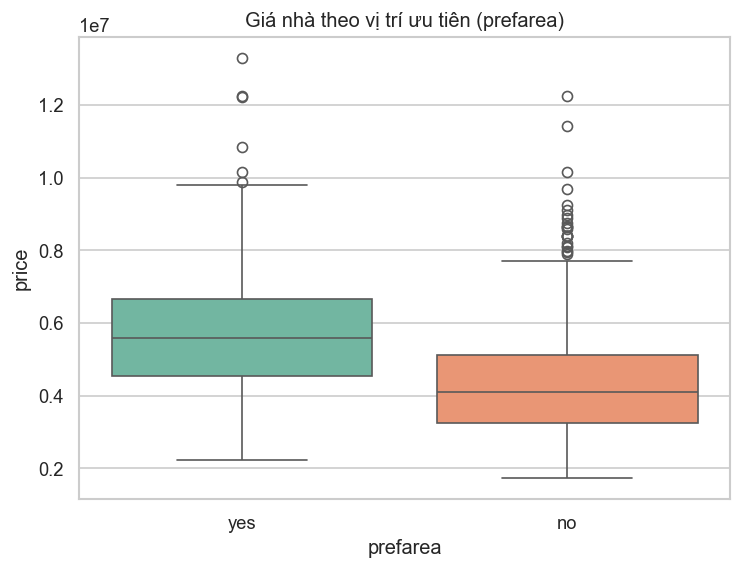

In [16]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="prefarea", y="price", hue="prefarea", palette="Set2", legend=False)
plt.title("Giá nhà theo vị trí ưu tiên (prefarea)")
plt.xlabel("prefarea")
plt.ylabel("price")
plt.show()


Bảng thống kê theo nhóm và boxplot bổ sung cho thấy nhóm `prefarea = yes` có giá trung bình và trung vị cao hơn nhóm `prefarea = no`. Vì vậy, `prefarea` là một biến phân loại đáng chú ý khi phân tích mối liên hệ với giá nhà.

In [17]:
outlier_summary = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,price,3430000.0,5740000.0,2310000.0,-35000.0,9205000.0,15
1,area,3600.0,6360.0,2760.0,-540.0,10500.0,12
2,bedrooms,2.0,3.0,1.0,0.5,4.5,12
3,bathrooms,1.0,2.0,1.0,-0.5,3.5,1
4,stories,1.0,2.0,1.0,-0.5,3.5,41
5,parking,0.0,1.0,1.0,-1.5,2.5,12


Bảng trên cho thấy một số biến như `price`, `area` hoặc `stories` có xuất hiện outlier theo quy tắc IQR. Tuy nhiên, đây vẫn có thể là các giá trị hợp lệ trong thực tế nên nhóm giữ lại dữ liệu và tiếp tục kiểm tra mức độ ổn định của mô hình hồi quy.


Từ kết quả phân tích sơ bộ, có thể thấy một số thuộc tính như `area`, `bathrooms`, `airconditioning` và `prefarea` có mối liên hệ với giá nhà. Vì vậy, nhóm lựa chọn mô hình hồi quy tuyến tính đa biến để xây dựng mô hình dự đoán.

## 5. Xây dựng mô hình hồi quy

Ở bước này, nhóm tiến hành mã hóa các biến phân loại, chia dữ liệu thành tập huấn luyện và tập kiểm tra, sau đó huấn luyện mô hình hồi quy tuyến tính đa biến.


In [18]:
df_model = df.copy()

binary_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
]

for col in binary_cols:
    df_model[col] = df_model[col].map({"yes": 1, "no": 0})

df_model = pd.get_dummies(df_model, columns=["furnishingstatus"], drop_first=True, dtype=int)

df_model.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [19]:
X = df_model.drop(columns=["price"])
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*encountered in matmul")
    y_pred = linear_model.predict(X_test)

baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)


In [20]:
mean_test_price = y_test.mean()

metric_df = pd.DataFrame(
    [
        {
            "Mô hình": "Baseline: dự đoán giá trung bình",
            "MAE": mean_absolute_error(y_test, y_pred_baseline),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_baseline)),
            "R²": r2_score(y_test, y_pred_baseline),
        },
        {
            "Mô hình": "Linear Regression",
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R²": r2_score(y_test, y_pred),
        },
    ]
)
metric_df["MAE / giá TB test"] = metric_df["MAE"] / mean_test_price
metric_df["RMSE / giá TB test"] = metric_df["RMSE"] / mean_test_price

metric_df_display = metric_df.copy()
for col in ["MAE", "RMSE"]:
    metric_df_display[col] = metric_df_display[col].map(lambda value: f"{value:,.0f}")
metric_df_display["R²"] = metric_df_display["R²"].map(lambda value: f"{value:.3f}")
for col in ["MAE / giá TB test", "RMSE / giá TB test"]:
    metric_df_display[col] = metric_df_display[col].map(lambda value: f"{value:.1%}")

metric_df_display


,Mô hình,MAE,RMSE,R²,MAE / giá TB test,RMSE / giá TB test
0,Baseline: dự đoán giá trung bình,"1,748,625","2,268,298",-0.018,34.9%,45.3%
1,Linear Regression,"970,043","1,324,507",0.653,19.4%,26.5%


In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
models_for_cv = {
    "Baseline: dự đoán giá trung bình": DummyRegressor(strategy="mean"),
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
}

cv_rows = []
for model_name, estimator in models_for_cv.items():
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*encountered in matmul")
        cv_mae = -cross_val_score(estimator, X, y, cv=cv, scoring="neg_mean_absolute_error")
        cv_rmse = np.sqrt(-cross_val_score(estimator, X, y, cv=cv, scoring="neg_mean_squared_error"))
        cv_r2 = cross_val_score(estimator, X, y, cv=cv, scoring="r2")
    cv_rows.append({
        "Mô hình": model_name,
        "CV MAE mean": cv_mae.mean(),
        "CV MAE std": cv_mae.std(),
        "CV RMSE mean": cv_rmse.mean(),
        "CV RMSE std": cv_rmse.std(),
        "CV R² mean": cv_r2.mean(),
        "CV R² std": cv_r2.std(),
    })

cv_df = pd.DataFrame(cv_rows)
cv_df_display = cv_df.copy()
for col in ["CV MAE mean", "CV MAE std", "CV RMSE mean", "CV RMSE std"]:
    cv_df_display[col] = cv_df_display[col].map(lambda value: f"{value:,.0f}")
for col in ["CV R² mean", "CV R² std"]:
    cv_df_display[col] = cv_df_display[col].map(lambda value: f"{value:.3f}")

cv_df_display


,Mô hình,CV MAE mean,CV MAE std,CV RMSE mean,CV RMSE std,CV R² mean,CV R² std
0,Baseline: dự đoán giá trung bình,"1,446,032","205,141","1,848,651","322,738",-0.034,0.043
1,Linear Regression,"807,180","111,996","1,084,538","143,763",0.632,0.074


Bảng đánh giá cho thấy mô hình Linear Regression tốt hơn baseline dự đoán giá trung bình trên cùng tập kiểm tra. Ngoài giá trị tuyệt đối của `MAE` và `RMSE`, nhóm quy đổi sai số theo tỷ lệ so với giá trung bình của tập test để diễn giải mức sai số dễ hơn. Kết quả cross-validation 5-fold được dùng để kiểm tra độ ổn định của mô hình trên nhiều cách chia dữ liệu, thay vì chỉ phụ thuộc vào một lần `train_test_split`.

In [22]:
standardized_model = make_pipeline(StandardScaler(), LinearRegression())
standardized_model.fit(X_train, y_train)
standardized_coefs = standardized_model.named_steps["linearregression"].coef_

coef_df = pd.DataFrame(
    {
        "Biến": X.columns,
        "Hệ số gốc": linear_model.coef_,
        "Hệ số chuẩn hóa": standardized_coefs,
    }
).sort_values(by="Hệ số chuẩn hóa", key=lambda s: s.abs(), ascending=False)

coef_df_display = coef_df.copy()
coef_df_display["Hệ số gốc"] = coef_df_display["Hệ số gốc"].map(lambda value: f"{value:,.0f}")
coef_df_display["Hệ số chuẩn hóa"] = coef_df_display["Hệ số chuẩn hóa"].map(lambda value: f"{value:,.0f}")
coef_df_display


,Biến,Hệ số gốc,Hệ số chuẩn hóa
2,bathrooms,"1,094,445","521,879"
0,area,236,"519,552"
8,airconditioning,"791,427","365,157"
3,stories,"407,477","349,251"
10,prefarea,"629,891","266,656"
12,furnishingstatus_unfurnished,"-413,645","-192,016"
9,parking,"224,842","192,006"
6,basement,"390,251","187,068"
7,hotwaterheating,"684,650","149,863"
4,mainroad,"367,920","128,499"


Bảng hệ số hồi quy gồm cả hệ số gốc và hệ số chuẩn hóa. Hệ số gốc cho biết mức thay đổi dự đoán theo đúng đơn vị ban đầu của từng biến, nên không nên dùng trực tiếp để so sánh độ mạnh giữa `area`, biến yes/no và các biến one-hot. Để so sánh tương đối giữa các biến, nhóm sử dụng cột `Hệ số chuẩn hóa`, tức mức thay đổi dự đoán khi một biến tăng 1 độ lệch chuẩn trong khi các biến khác giữ nguyên.

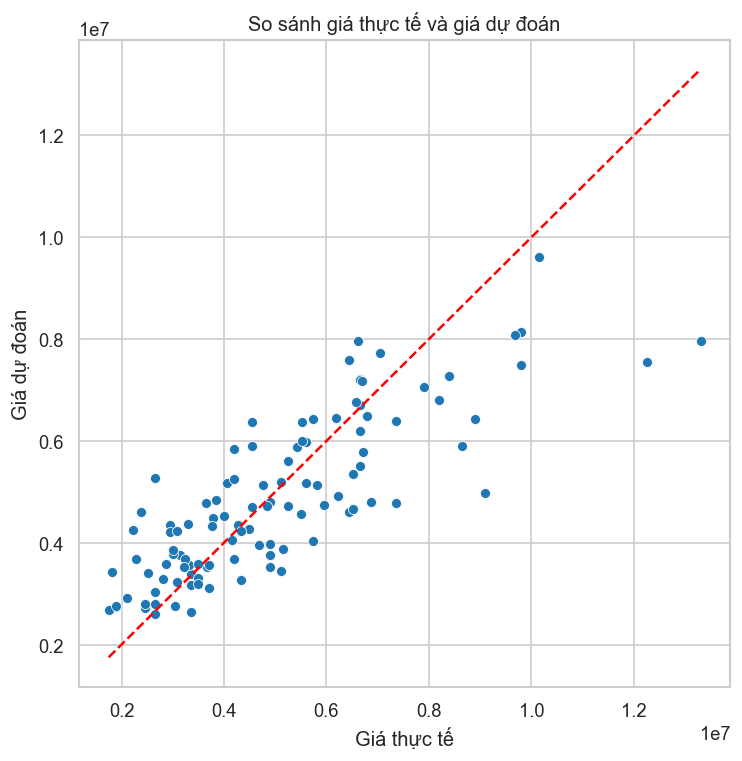

In [23]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, color="#1f77b4")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("So sánh giá thực tế và giá dự đoán")
plt.show()


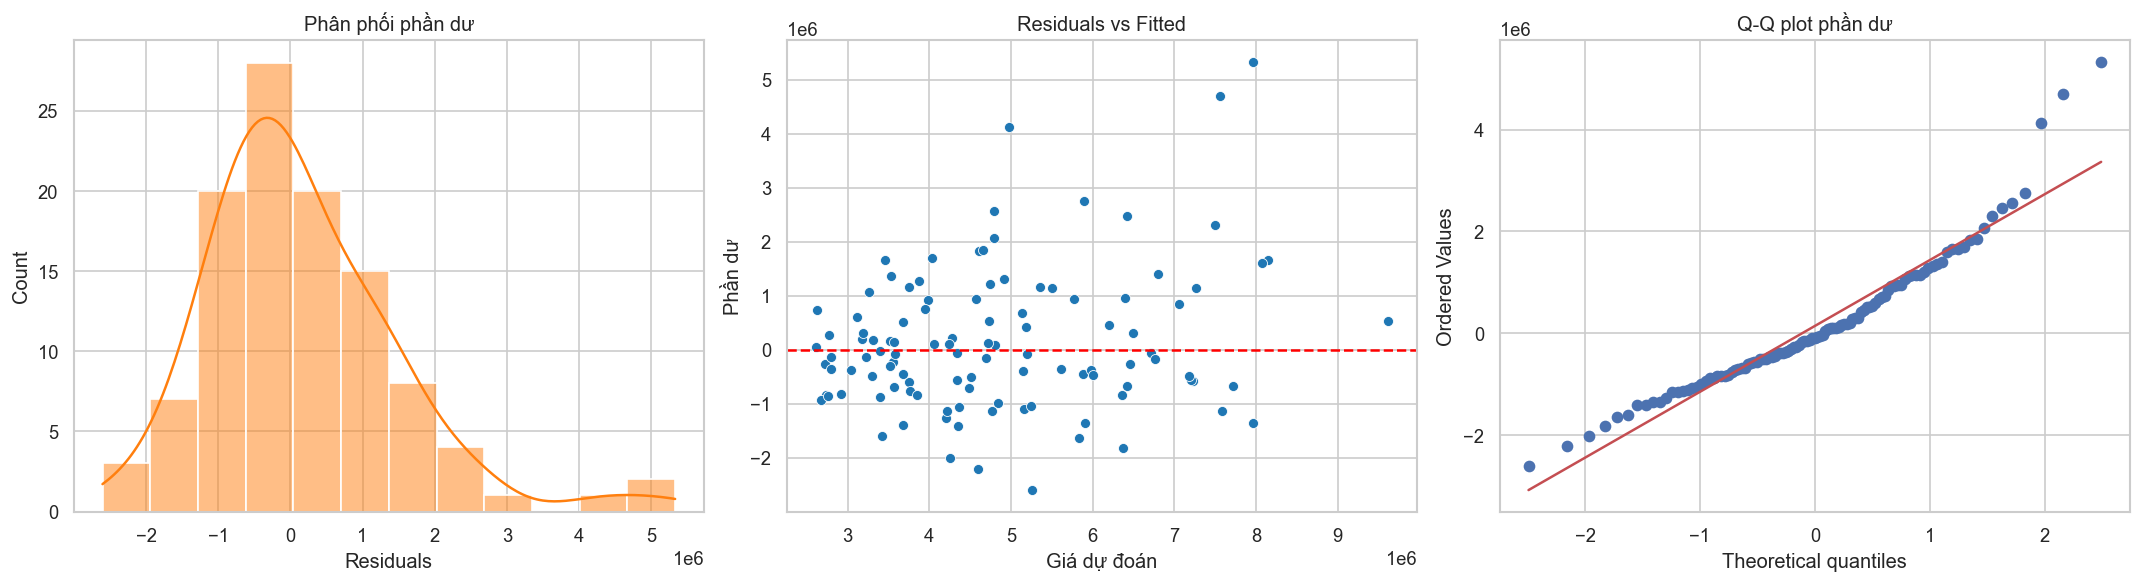

In [24]:
residuals = y_test - y_pred
fitted_values = y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(residuals, kde=True, color="#ff7f0e", ax=axes[0])
axes[0].set_title("Phân phối phần dư")
axes[0].set_xlabel("Residuals")

sns.scatterplot(x=fitted_values, y=residuals, color="#1f77b4", ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs Fitted")
axes[1].set_xlabel("Giá dự đoán")
axes[1].set_ylabel("Phần dư")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot phần dư")

plt.tight_layout()
plt.show()


Biểu đồ phần dư giúp kiểm tra nhanh giả định của hồi quy tuyến tính. Histogram và Q-Q plot cho biết phần dư có gần phân phối chuẩn hay không, còn biểu đồ `Residuals vs Fitted` giúp quan sát phần dư có phân tán ngẫu nhiên quanh 0 hay xuất hiện dấu hiệu phương sai thay đổi.

## 6. Kết quả phân tích

Qua quá trình phân tích, nhóm nhận thấy diện tích, số phòng tắm, vị trí ưu tiên và các tiện nghi như điều hòa có mối liên hệ tích cực với giá nhà. Mô hình hồi quy tuyến tính đa biến lượng hóa các mối liên hệ này và cho kết quả dự đoán tốt hơn baseline dự đoán giá trung bình, thể hiện qua bảng metric và kết quả cross-validation ở trên.

Bên cạnh đó, dữ liệu vẫn tồn tại outlier và độ phân tán khá lớn ở biến `price`, nên kết quả dự đoán có thể sai lệch ở một số trường hợp đặc biệt. Các biểu đồ phần dư cho thấy cần tiếp tục thận trọng với giả định tuyến tính và phương sai không đổi khi sử dụng mô hình hồi quy tuyến tính cho bộ dữ liệu này.

## 7. Kết luận

Bài toán phân tích và dự đoán giá nhà cho thấy giá nhà có mối liên hệ với nhiều thuộc tính khác nhau, trong đó diện tích, số phòng tắm, vị trí ưu tiên và một số tiện nghi là các biến nổi bật trong bộ dữ liệu. Thông qua quá trình phân tích thăm dò, chuẩn hóa hệ số hồi quy và đánh giá mô hình, nhóm có thể rút ra các đặc trưng quan trọng và áp dụng chúng để dự đoán giá nhà.

Trong tương lai, nhóm có thể thử thêm các mô hình khác như Ridge, Lasso hoặc Random Forest để so sánh hiệu quả dự đoán. Vì `price` và `area` có phân phối lệch phải và tồn tại outlier, nhóm cũng nên thử biến đổi `log(price)` hoặc các phương pháp hồi quy bền vững hơn để kiểm tra khả năng cải thiện độ chính xác.